Complete Exercise  4 using Pandas\
After that complete the following
1. Read NIRF data as given in Dataset tab on Google Classroom.
2. Group the data statewise and Count the number of colleges in each state.
3.  Sort the records based on rpc attribute (Research Professional practices).
4. Find the rank of Panjab University as per rpc attribute.
5. List the colleges whose rpc value is less than Panjab University and rank is higher(rank value is less).
6. Draw the Histogram for colleges based on tlr values by dividing the overall data in 10 bins.

### Exercise 4

Solve:
1. Find mean, std dev, min , max of unitprice field.
2. Draw histogram of unitprice field using matplotlib
3. Find mean of unitprice group by country and plot them
4. Find min and max of unit price group by customerID
5. Find cumulative sales monthly and yearly and plot them using both Matplotlib and Sea Borne.
6. Generate a Box plot for each attribute
7. Analyze each attribute using the factor plot analysis using Seaborne library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../../datasets/OnlineRetail.csv", encoding="latin-1", parse_dates=["InvoiceDate"]
)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [5]:
unitprice_col = df["UnitPrice"]

In [6]:
print(f"Mean: {unitprice_col.mean()}")
print(f"Std deviation: {unitprice_col.std()}")
print(f"Max: {unitprice_col.max()}")
print(f"Min: {unitprice_col.min()}")

Mean: 4.611113626088514
Std deviation: 96.75985306117937
Max: 38970.0
Min: -11062.06


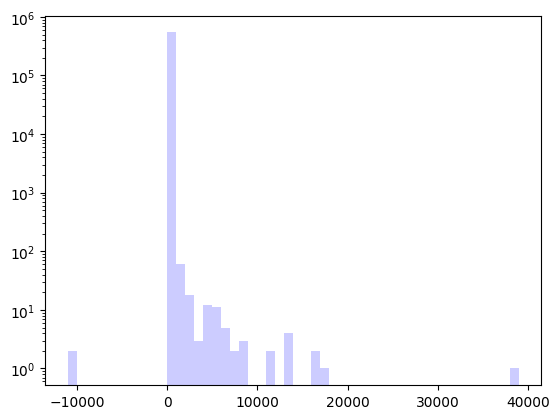

In [7]:
_ = plt.hist(unitprice_col, 50, facecolor="b", alpha=0.2)
plt.yscale("log")

In [8]:
gb_country = df.groupby("Country", as_index=False)["UnitPrice"].mean()
gb_country.head()

,Country,UnitPrice
0,Australia,3.220612
1,Austria,4.243192
2,Bahrain,4.556316
3,Belgium,3.644335
4,Brazil,4.456250


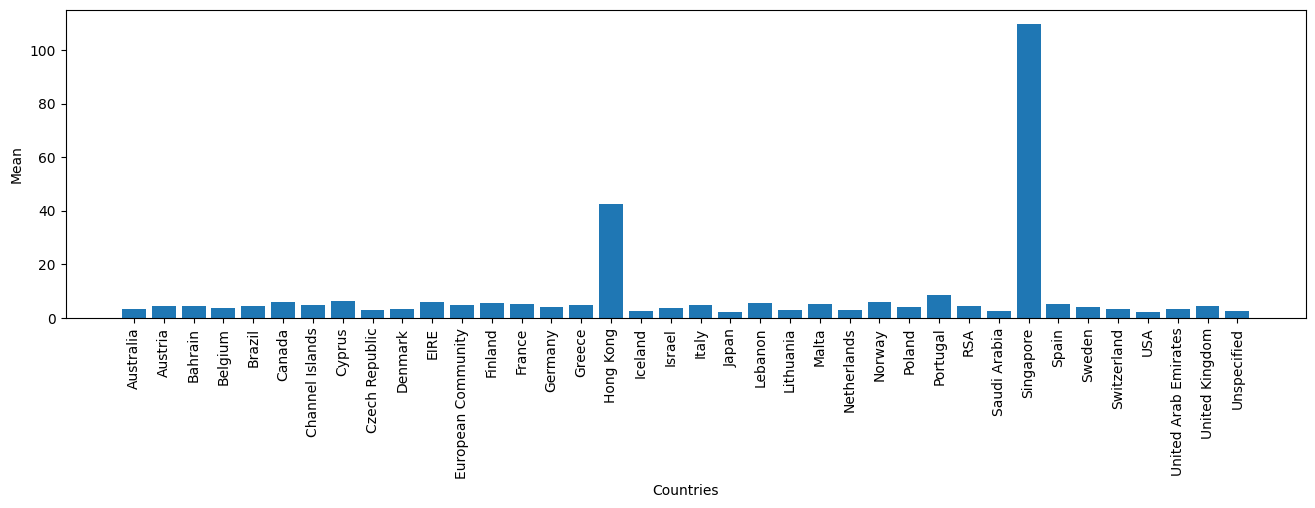

In [9]:
x = gb_country["Country"]
y = gb_country["UnitPrice"]
plt.figure(figsize=(16, 4))
plt.bar(x, y)
plt.xticks(rotation=90)
plt.xlabel("Countries")
plt.ylabel("Mean")
plt.show()

In [10]:
cust_min_max = df.groupby("CustomerID", as_index=False)["UnitPrice"].agg(["min", "max"])
cust_min_max.head()

,CustomerID,min,max
0,12346.0,1.04,1.04
1,12347.0,0.25,12.75
2,12348.0,0.29,40.00
3,12349.0,0.42,300.00
4,12350.0,0.85,40.00


In [11]:
df["Month"] = df["InvoiceDate"].dt.month
df["Year"] = df["InvoiceDate"].dt.year
df["Sales"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Year,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2010,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2010,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010,20.34


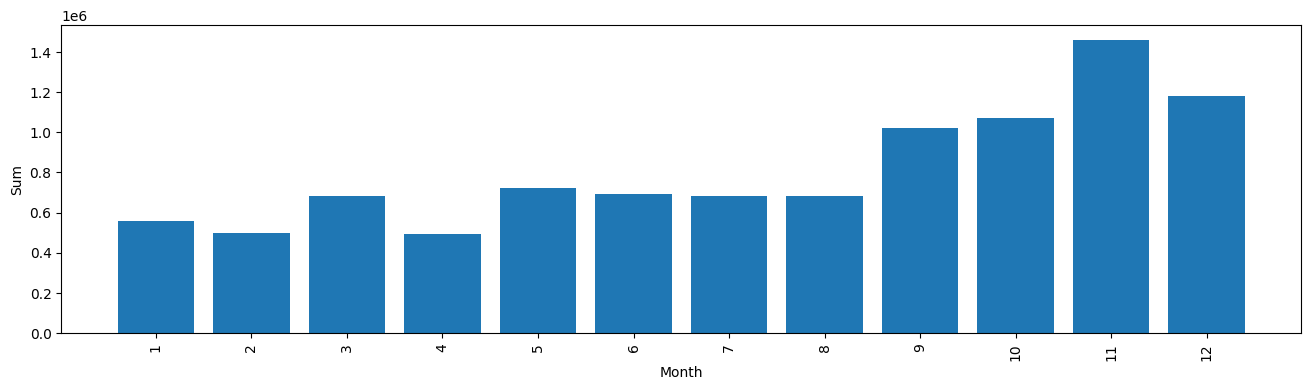

In [12]:
month_sum = df.groupby("Month", as_index=False)[["Sales"]].sum()
x = month_sum["Month"]
y = month_sum["Sales"]
plt.figure(figsize=(16, 4))
plt.bar(x, y)
plt.xticks(x, rotation=90)
plt.xlabel("Month")
plt.ylabel("Sum")
plt.show()


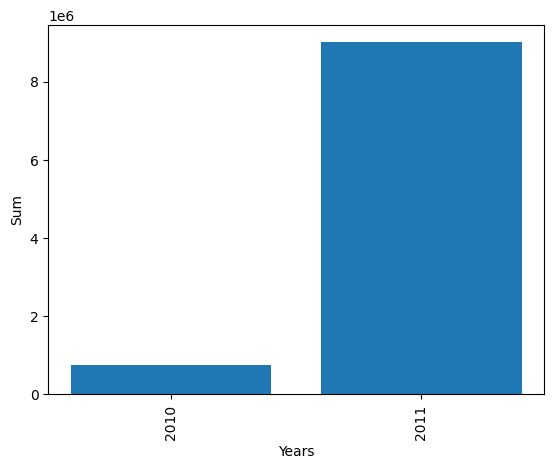

In [13]:
year_sum = df.groupby("Year", as_index=False)[["Sales"]].sum()
x = year_sum["Year"]
y = year_sum["Sales"]
plt.bar(x, y)
plt.xticks(x, rotation=90)
plt.xlabel("Years")
plt.ylabel("Sum")
plt.show()

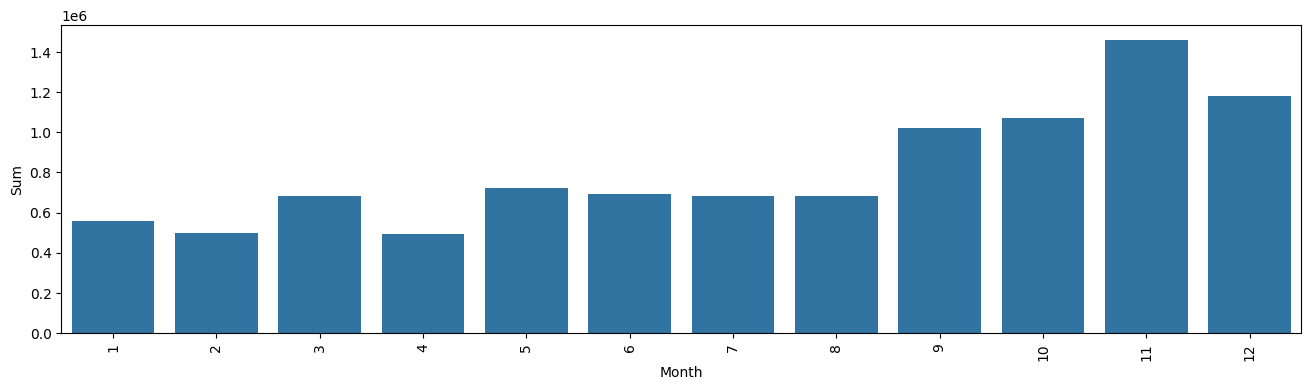

In [14]:
month_sum = df.groupby("Month", as_index=False)[["Sales"]].sum()
plt.figure(figsize=(16, 4))
sns.barplot(month_sum, x="Month", y="Sales")
plt.xticks(rotation=90)
plt.xlabel("Month")
plt.ylabel("Sum")
plt.show()


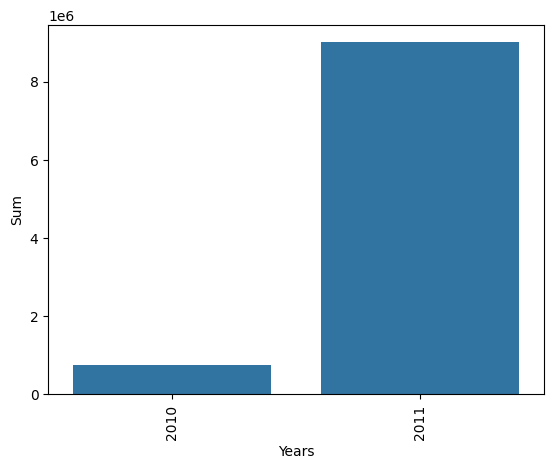

In [15]:
year_sum = df.groupby("Year", as_index=False)[["Sales"]].sum()
sns.barplot(year_sum, x="Year", y="Sales")
plt.xticks(rotation=90)
plt.xlabel("Years")
plt.ylabel("Sum")
plt.show()

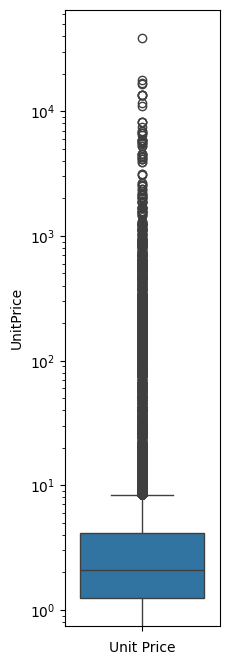

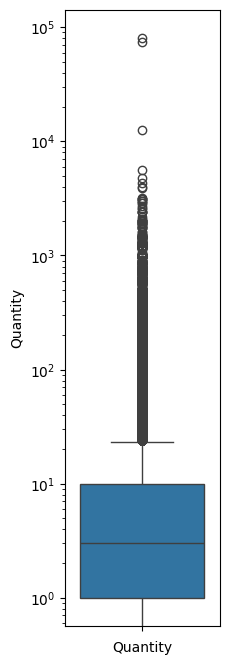

In [17]:
plt.figure(figsize=(2, 8))
sns.boxplot(df["UnitPrice"])
plt.yscale("log")
plt.xticks(rotation=90)
plt.xlabel("Unit Price")
plt.show()

plt.figure(figsize=(2, 8))
sns.boxplot(df["Quantity"])
plt.yscale("log")
plt.xticks(rotation=90)
plt.xlabel("Quantity")
plt.show()

<Figure size 1600x400 with 0 Axes>

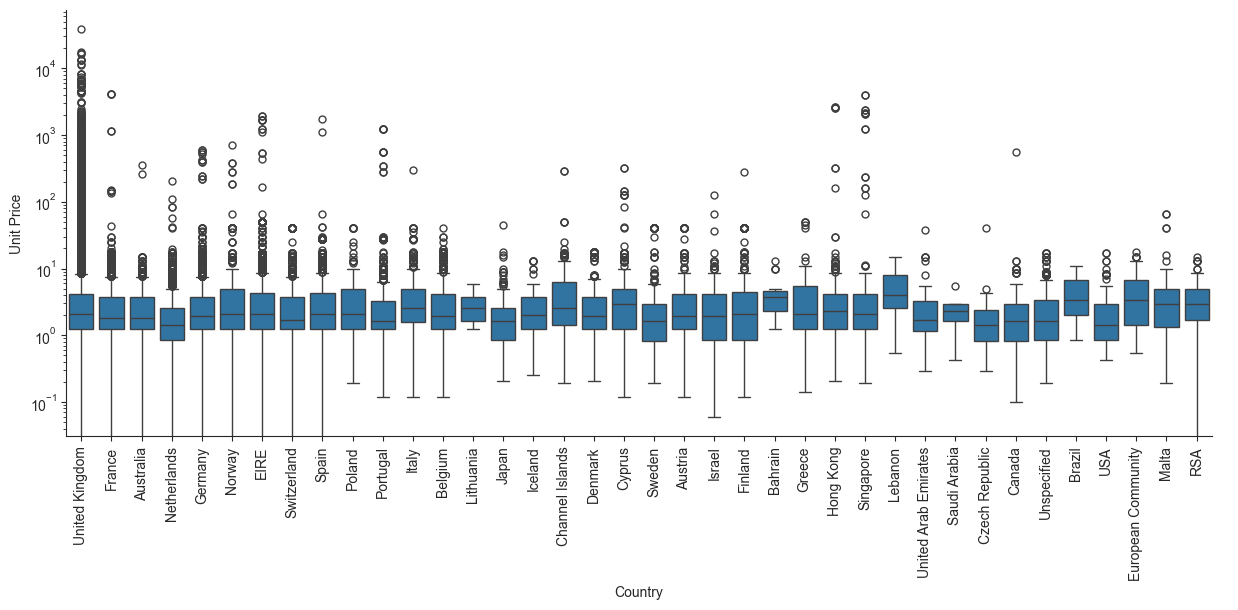

<Figure size 1600x400 with 0 Axes>

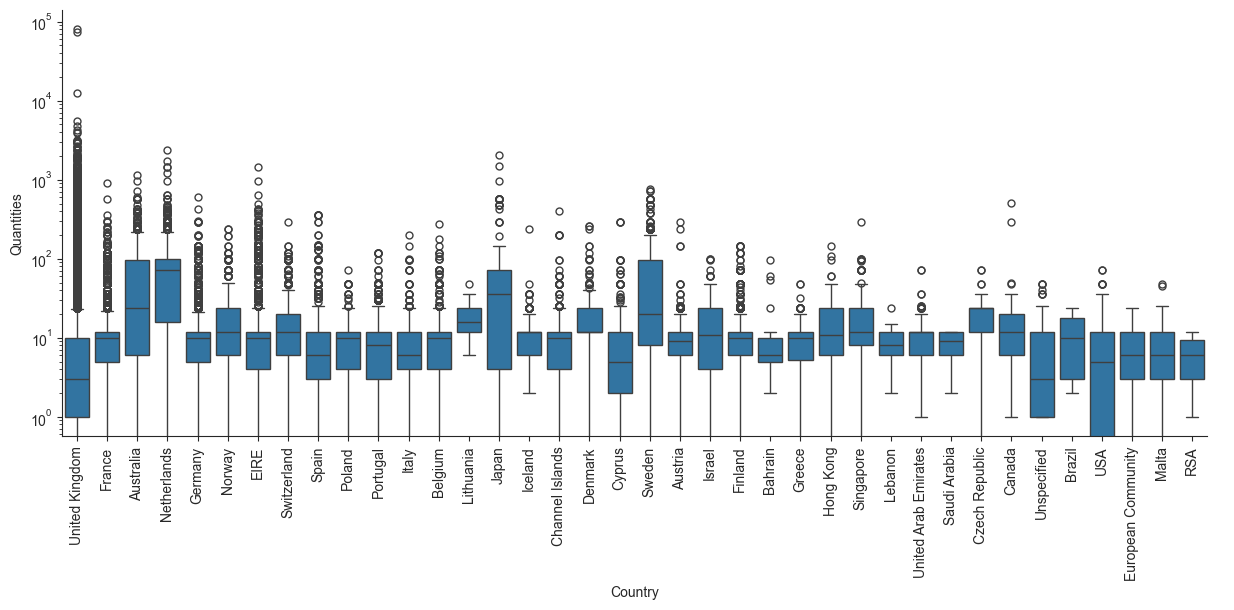

In [18]:
with sns.axes_style(style="ticks"):
    plt.figure(figsize=(16, 4))
    g = sns.catplot(df, x="Country", y="UnitPrice", kind="box", height=5, aspect=2.5)
    plt.xticks(rotation=90)
    g.set_axis_labels("Country", "Unit Price")
    plt.yscale("log")
    plt.show()

with sns.axes_style(style="ticks"):
    plt.figure(figsize=(16, 4))
    g = sns.catplot(df, x="Country", y="Quantity", kind="box", height=5, aspect=2.5)
    plt.xticks(rotation=90)
    g.set_axis_labels("Country", "Quantities")
    plt.yscale("log")
    plt.show()

### Exercise 6

1. Read NIRF data as given in Dataset tab on Google Classroom.
2. Group the data statewise and Count the number of colleges in each state.
3. Sort the records based on rpc attribute (Research Professional practices).
4. Find the rank of Panjab University as per rpc attribute.
5. List the colleges whose rpc value is less than Panjab University and rank is higher(rank value is less).
6. Draw the Histogram for colleges based on tlr values by dividing the overall data in 10 bins.

In [20]:
df = pd.read_csv("../../datasets/nirf_engg_ranking_india_2020.csv")
df.head()

,institute_id,name,link,tlr,rpc,go,oi,perception,city,state,score,rank
0,IR-E-U-0456,Indian Institute of Technology Madras,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,95.42,94.64,83.90,61.31,100.00,Chennai,Tamil Nadu,89.93,1
1,IR-E-I-1074,Indian Institute of Technology Delhi,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,90.79,96.15,80.36,64.81,94.46,New Delhi,Delhi,88.08,2
2,IR-E-U-0306,Indian Institute of Technology Bombay,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,91.00,93.37,77.60,49.99,92.51,Mumbai,Maharashtra,85.08,3
3,IR-E-I-1075,Indian Institute of Technology Kanpur,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,86.22,82.08,88.44,54.21,85.78,Kanpur,Uttar Pradesh,82.18,4
4,IR-E-U-0573,Indian Institute of Technology Kharagpur,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,77.32,87.11,83.21,56.62,89.31,Kharagpur,West Bengal,80.56,5


In [21]:
df.dtypes

institute_id        str
name                str
link                str
tlr             float64
rpc             float64
go              float64
oi              float64
perception      float64
city                str
state               str
score           float64
rank              int64
dtype: object

In [23]:
state_count = df.groupby("state", as_index=False)["institute_id"].count()
state_count.head()

,state,institute_id
0,Andhra Pradesh,10
1,Arunachal Pradesh,2
2,Assam,3
3,Bihar,2
4,Chandigarh,2


In [25]:
sorted_df = df.sort_values(by=["rpc"])
sorted_df.head()

,institute_id,name,link,tlr,rpc,go,oi,perception,city,state,score,rank
198,IR-E-C-48145,BVRIT Hyderabad,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,49.16,0.46,53.74,52.98,1.63,Hyderabad,Telangana,31.10,199
146,IR-E-C-1345,P E S College of Engineering,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,59.25,0.71,51.11,54.45,0.00,Mandya,Karnataka,33.65,147
186,IR-E-C-26162,Vasavi College of Engineering,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,48.80,0.75,56.58,50.47,2.16,Hyderabad,Telangana,31.46,187
185,IR-E-C-1398,BNM Institute of Technology,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,55.66,1.11,46.87,50.80,0.00,Bengaluru,Karnataka,31.48,186
189,IR-E-C-26905,G.Pulla Reddy Engineering College,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,53.11,1.15,48.27,51.60,2.69,Kurnool,Andhra Pradesh,31.35,190


In [30]:
pu_info = df.loc[df["name"] == "Panjab University", ["rpc", "rank"]]
pu_rpc = pu_info["rpc"].values[0]
pu_rank = pu_info["rank"].values[0]
print(pu_rpc)
print(pu_rank)

43.55
72


In [34]:
worse_than_pu = df.loc[(df["rpc"] < pu_rpc) & (df["rank"] > pu_rank), :]
worse_than_pu.head()

,institute_id,name,link,tlr,rpc,go,oi,perception,city,state,score,rank
72,IR-E-C-1262,B.M.S. College of Engineering,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,62.07,11.92,55.53,52.58,17.79,Bengaluru,Karnataka,40.35,73
73,IR-E-C-45375,Indian Institute of Food Processing Technology...,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,70.18,5.41,53.50,58.94,9.84,Thanjavur,Tamil Nadu,40.24,74
74,IR-E-U-0493,National Institute of Technology Agartala,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,57.69,21.55,48.22,55.37,10.27,Agratala,Tripura,39.98,75
75,IR-E-C-6379,Netaji Subhas University of Technology (NSUT),https://nirfcdn.azureedge.net/2020/pdf/Enginee...,49.60,22.68,62.41,44.55,13.60,South West,Delhi,39.97,76
76,IR-E-U-0620,National Institute of Technology Goa,https://nirfcdn.azureedge.net/2020/pdf/Enginee...,57.39,18.33,52.11,56.77,11.13,Ponda,Goa,39.93,77


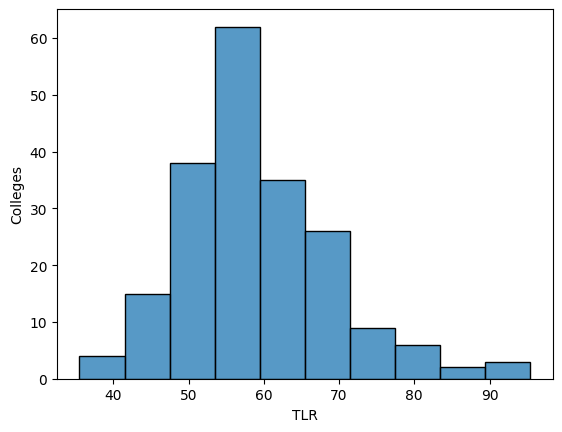

In [38]:
sns.histplot(df["tlr"], bins=10)
plt.xlabel("TLR")
plt.ylabel("Colleges")
plt.show()